Enter how many elements: 2
Enter how many nodes: 3
Enter the number of nodes that are constrained: 1
Enter coordinates for node 1 (x y) in m: 0 0
Enter coordinates for node 2 (x y) in m: 0 1
Enter coordinates for node 3 (x y) in m: 1 1
Enter the node numbers for element 1 (start end): 1 2
Enter the node numbers for element 2 (start end): 2 3
(n=node number, x,y=0 if no constraint, 1 if there is constraint (n x y theta)): 1 1 1 1
(n=node number, fx, fy, M = 0 if no force, magnitude (in kN/kNm), 1 if there is force (n fx fy M)): 2 0 0 0 
(n=node number, fx, fy, M = 0 if no force, magnitude (in kN/kNm), 1 if there is force (n fx fy M)): 3 0 -0.02 0
Element Stiffness Matrices:
Element 1:
[[ 1.999992e+00  0.000000e+00  9.999960e+02 -1.999992e+00 -0.000000e+00
   9.999960e+02]
 [ 0.000000e+00  2.000000e+04 -0.000000e+00 -0.000000e+00 -2.000000e+04
  -0.000000e+00]
 [ 9.999960e+02 -0.000000e+00  6.666640e+05 -9.999960e+02  0.000000e+00
   3.333320e+05]
 [-1.999992e+00  0.000000e+00 -9.999960e

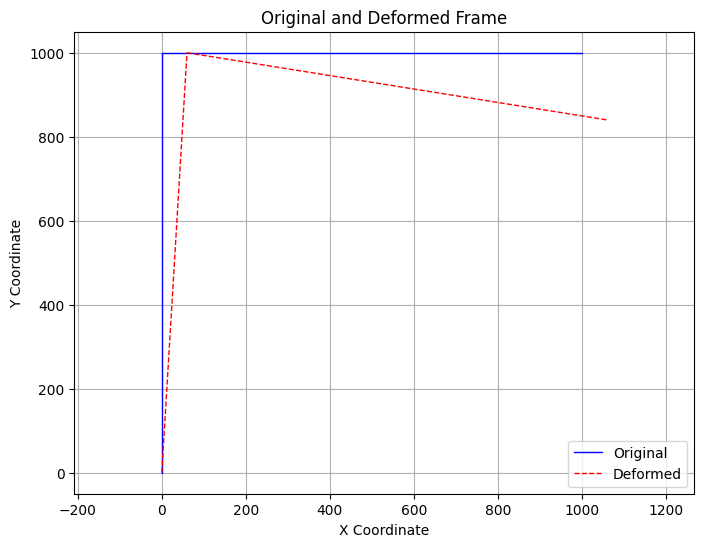

In [ ]:
#########  SOLVING BEAMS AND 2D-FRAMES USING FEM  #########

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# Geometric inputs
elements = int(input("Enter how many elements: ")) # Number of Elements
nodes = int(input("Enter how many nodes: ")) # Number of Nodes
constraints = int(input("Enter the number of nodes that are constrained: "))
force = nodes - constraints
A = 100.0 # Area (mm2)
I = 833.33 # Moment of Inertia (mm4)
E = 200000.0 # Modulus of Elasticity (MPa)

# Initialize arrays
node_coordinates = np.zeros((nodes, 2))  # 2D coordinates (x, y)
element_connectivity = np.zeros((elements, 2), dtype=int)
constraints_x_y_theta = np.zeros((constraints, 4)) # (Node, x, y, theta)
external_forces = np.zeros((force, 4))
element_orientation = np.zeros(elements)
element_length = np.zeros(elements)
element_stiffness_matrices = []
element_direction = np.zeros((elements, 6))
global_stiffness_matrix = np.zeros((3*nodes, 3*nodes))

# Define symbols for displacements and forces
u_vars = sp.symbols(f'u1:{(3*nodes)+1}')
node_displacements = sp.Matrix(u_vars)
f_vars = sp.symbols(f'f1:{(3*nodes)+1}')
node_forces = sp.Matrix(f_vars)

# Loop to get coordinates for each node
for i in range(nodes):
  coord_input = input(f"Enter coordinates for node {i+1} (x y) in m: ").split()
  x = float(coord_input[0]) * 1000.0
  y = float(coord_input[1]) * 1000.0
  node_coordinates[i] = [x, y]

# Loop to get the node connectivity for each element
for i in range(elements):
  n1, n2 = map(int, input(f"Enter the node numbers for element {i+1} (start end): ").split())
  element_connectivity[i] = [n1, n2]

# Loop to get Boundary Conditions
for i in range(constraints):
  node, x, y,theta = map(float, input(f"(n=node number, x,y=0 if no constraint, 1 if there is constraint (n x y theta)): ").split())
  constraints_x_y_theta[i] = [node, x, y, theta]

# Loop to get element directions
dof = np.arange(1, 3*nodes+1)
directions = dof.reshape(-1, 3)
for i in range(elements):
  n1, n2 = element_connectivity[i]
  a, b, c = directions[n1-1]
  d, e, f = directions[n2-1]
  element_direction[i] = [a-1, b-1, c-1, d-1, e-1, f-1]

# Apply the constraints to the node_displacements matrix
for i in range(constraints):
  node, x_constraint, y_constraint, theta_constraint = constraints_x_y_theta[i]
  if x_constraint == 1:
    node_displacements[3*int(node)-3] = 0
  if y_constraint == 1:
    node_displacements[3*int(node)-2] = 0
  if theta_constraint == 1:
    node_displacements[3*int(node)-1] = 0
  if x_constraint == 0:
    node_forces[3*int(node)-3] = 0
  if y_constraint == 0:
    node_forces[3*int(node)-2] = 0
  if theta_constraint == 1:
    node_forces[3*int(node)-1] = 0

# Loop to get External Forces
for i in range(force):
  node_input = input(f"(n=node number, fx, fy, M = 0 if no force, magnitude (in kN/kNm), 1 if there is force (n fx fy M)): ").split()
  node = int(node_input[0])  # Ensure node is an integer
  fx = float(node_input[1]) * 1000.0  # Convert force to Newtons
  fy = float(node_input[2]) * 1000.0
  M = float(node_input[3]) * 1000000.0
  external_forces[i] = [node, fx, fy, M]

########## END OF INPUTS ##########

# Loop to calculate length, orientation and stiffness of each element
for i in range(elements):
  # Extracting Coordinates
  n1, n2 = element_connectivity[i]
  x1, y1 = node_coordinates[n1-1]
  x2, y2 = node_coordinates[n2-1]

  # Finding Length and Orientation
  h = round(np.sqrt((x2 - x1)**2 + (y2 - y1)**2), 2)
  theta = np.arctan2(y2 - y1, x2 - x1)
  element_length[i] = h
  element_orientation[i] = theta

  # Compute direction cosines
  c = round(np.cos(theta), 3)
  s = round(np.sin(theta), 3)
  mue = A * h * h * 0.5 / I

  # Compute element stiffness matrix
  k = (2 * E * I / (h**3)) * np.array([
      [c**2*mue + 6*s**2, c*s*(mue - 6), 3*h*s, -c**2*mue - 6*s**2, c*s*(6 - mue), 3*h*s],
      [c*s*(mue - 6), 6*c**2 + mue*s**2, -3*c*h, c*s*(6 - mue), -6*c**2 - mue*s**2, -3*c*h],
      [3*h*s, -3*c*h, 2*h**2, -3*h*s, 3*c*h, h**2],
      [-c**2*mue - 6*s**2, c*s*(mue + 6), -3*h*s, c**2*mue + 6*s**2, c*s*(mue - 6), -3*h*s],
      [c*s*(6 - mue), -6*c**2 - mue*s**2, 3*c*h, c*s*(mue - 6), 6*c**2 + mue*s**2, 3*c*h],
      [3*h*s, -3*c*h, h**2, -3*h*s, 3*c*h, 2*h**2]
    ])

  # Store the stiffness matrix
  element_stiffness_matrices.append(k)

# Generating Global Stiffness Matrix
for i in range(elements):
  indices = element_direction[i]
  for j in range(6):
    for k in range(6):
        global_stiffness_matrix[int(indices[j]), int(indices[k])] += round(element_stiffness_matrices[i][j, k], 3)

# Apply Force values to node forces matrix
for i in range(force):
  node, fx, fy, theta = external_forces[i]
  node_forces[3*int(node)-3] = fx
  node_forces[3*int(node)-2] = fy
  node_forces[3*int(node)-1] = theta

# Printing Element Stiffness Matrix of Each Element
print("Element Stiffness Matrices:")
for i, k in enumerate(element_stiffness_matrices):
  print(f"Element {i+1}:")
  print(k)

# Printing U, F and K Matrices
print("Node Displacements:")
print(node_displacements)
print("Node Forces:")
print(node_forces)
print("Global Stiffness Matrix:")
print(global_stiffness_matrix)

# Seggregating known and unknown dofs
constrained_dofs = []
free_dofs = []
for i in range(3 * nodes):
  if node_displacements[i] == 0:  # Constrained DOFs (from BCs)
    constrained_dofs.append(i)
  else:
    free_dofs.append(i)  # Unconstrained DOFs (Unknown Displacements)

# Extracting Sub Matrix for free DOFs of Force
F_known = []
for i in free_dofs:
  F_known.append(node_forces[i])

# Converting K and F to Symbolic Matrix
K = sp.Matrix(global_stiffness_matrix)
F_known = sp.Matrix(F_known)

# Extracting Sub Matrix for free DOFs of Stiffness
K_free = K.extract(free_dofs, free_dofs)

# Solve for unknown displacements
solution = sp.linsolve([K_free, F_known], *[u_vars[i] for i in free_dofs])

# Convert solution to dictionary for substitution
solution_dict = {}
if solution:
  displacement_values = solution.args[0]  # Extract solution tuple
  for idx, val in enumerate(displacement_values):
    solution_dict[u_vars[free_dofs[idx]]] = val

# Fill in the full displacement vector
full_displacement = node_displacements.copy()
for dof in free_dofs:
  full_displacement[dof] = solution_dict[u_vars[dof]]
full_displacement = full_displacement.applyfunc(lambda x: x.evalf(6))

print("\nFull Displacement(mm) Matrix:")
print(full_displacement)

# Calculate the full force vector using F = K * U
F_calculated = K * full_displacement
F_calculated = F_calculated.applyfunc(lambda x: x.evalf(6))

print("\nFull Force(N), Moment(Clockwise +) Vector:")
print(F_calculated)

# Calculating Member Forces
member_forces = []

for i in range(elements):
  indices = element_direction[i].astype(int)
  u_e = np.array([full_displacement[idx] for idx in indices])  # Extract element displacements
  Q_e = np.array([F_calculated[idx] for idx in indices])  # Extract element forces
  alpha = element_orientation[i]

  # Extracting nodal displacements and forces
  u_1e = u_e[0]
  u_2e = u_e[1]
  u_4e = u_e[3]
  u_5e = u_e[4]
  Q_1e = Q_e[0]
  Q_2e = Q_e[1]
  Q_3e = Q_e[2]

  # Compute direction cosines
  c = round(np.cos(alpha), 3)
  s = round(np.sin(alpha), 3)

  x = sp.Symbol(f'x_{i+1}')

  # Converting from Global to Local Coordinates
  len = element_length[i]
  Q_e_bar = (A*E/len) * (c*(u_4e - u_1e) + s*(u_5e - u_2e))
  member_forces.append(Q_e_bar)

# Print member forces
print("\nMember Forces(N) (C -,  T +):")
print(member_forces)

# Compute deformed coordinates
deformed_coordinates = node_coordinates.copy()
for i in range(nodes):
    deformed_coordinates[i, 0] += float(full_displacement[3 * i])
    deformed_coordinates[i, 1] += float(full_displacement[3 * i + 1])

# Create the figure
plt.figure(figsize=(8, 6))

# Plot the original frame
for i in range(elements):
    n1, n2 = element_connectivity[i]
    x_values = [node_coordinates[n1 - 1, 0], node_coordinates[n2 - 1, 0]]
    y_values = [node_coordinates[n1 - 1, 1], node_coordinates[n2 - 1, 1]]
    plt.plot(x_values, y_values, 'b-', linewidth=1, label="Original" if i == 0 else "")

# Plot the deformed frame
for i in range(elements):
    n1, n2 = element_connectivity[i]
    x_values = [deformed_coordinates[n1 - 1, 0], deformed_coordinates[n2 - 1, 0]]
    y_values = [deformed_coordinates[n1 - 1, 1], deformed_coordinates[n2 - 1, 1]]
    plt.plot(x_values, y_values, 'r--', linewidth=1, label="Deformed" if i == 0 else "")

# Labels, legend, and dynamic limits
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Original and Deformed Frame')
plt.legend()
plt.grid(True)
plt.axis('equal')

# Show the plot
plt.show()
